<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Baseline CNN
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">
<b>Notebook Description</b><br>
This notebook presents a baseline implementation of a Convolutional Neural Network (CNN) for image classification on the WikiArt dataset.
</div>

<br>

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>

In [1]:
import os
import sys

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import keras
from keras import layers

# Auto-reload local modules while editing this notebook
%load_ext autoreload
%autoreload 2
from warnings import filterwarnings
filterwarnings("ignore")

sys.path.append(os.path.abspath('../src'))

from utils import (
    evaluate_model,
    load_config,
    load_datasets,
    plot_learning_curves,
    save_history,
    set_seeds,
)

# Custom callback to manage GPU memory growth
from GPUGuard import GPUGuard

# Load config (relative to notebooks/)
config = load_config('../config.yml')
    
SEED = config['seed']
set_seeds(SEED)

<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Model Implementation
  </h2>
</div>

To establish a performance reference point, a deliberately simple CNN was implemented before developing more complex architectures. This baseline serves a clear methodological purpose: any added complexity - deeper networks, residual connections, transfer learning - must demonstrably outperform it to justify the associated computational cost and development effort.

The architecture is intentionally minimal:
- **2 convolutional blocks** (Conv2D + MaxPooling), with 32 and 64 filters respectively
- **GlobalAveragePooling** to reduce spatial dimensions before classification
- **Single Dense layer** (64 units) followed by a 23-class softmax output

Data augmentation and rescaling are applied inline as Keras layers, ensuring consistency between training and inference and keeping the pipeline self-contained.

Given the complexity of the WikiArt classification task (23 classes, high intra-class visual variability, and subtle stylistic differences between artists) this baseline is not expected to achieve strong performance. Its role is diagnostic: it provides a lower bound on accuracy and macro F1, against which the residual CNN and the fine-tuned transfer learnings can be objectively compared. Any model that fails to significantly exceed this baseline would indicate a fundamental issue in architecture design or training configuration.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = config['num_classes']

# by default, train for 100 epochs and rely on early stopping to prevent overfitting
MAX_EPOCHS = config['max_epochs']

# All paths relative to notebooks/
train_dir = config['paths']['train_dir']
val_dir = config['paths']['val_dir']
test_dir = config['paths']['test_dir']

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

# prefetch datasets for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=config['models']['baseline']['checkpoint'],
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95)
 ]

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [3]:
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = layers.Rescaling(1.0 / 255)(inputs)

x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cnn_baseline_small")

### Training

In [4]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

# Save model in models directory (relative to notebooks/)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
)

Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1179 - f1_macro: 0.0173 - loss: 3.0930
Epoch 1: val_loss improved from None to 3.02346, saving model to ../models/baseline/baseline_best.keras

Epoch 1: finished saving model to ../models/baseline/baseline_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.1147 - f1_macro: 0.0172 - loss: 3.0645 - val_accuracy: 0.1348 - val_f1_macro: 0.0205 - val_loss: 3.0235 - learning_rate: 1.0000e-04
Epoch 2/100
288/291 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1344 - f1_macro: 0.0200 - loss: 3.0182
Epoch 2: val_loss improved from 3.02346 to 2.96421, saving model to ../models/baseline/baseline_best.keras

Epoch 2: finished saving model to ../models/baseline/baseline_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.1403 - f1_macro: 0.0231 - loss: 3.0012 - val_accuracy: 0.1354 - val_f1_macro: 0.0275 - val_loss: 2.9642 - learning_rate: 1.0000e-04
Epoch 3/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/s

### Learning Curves

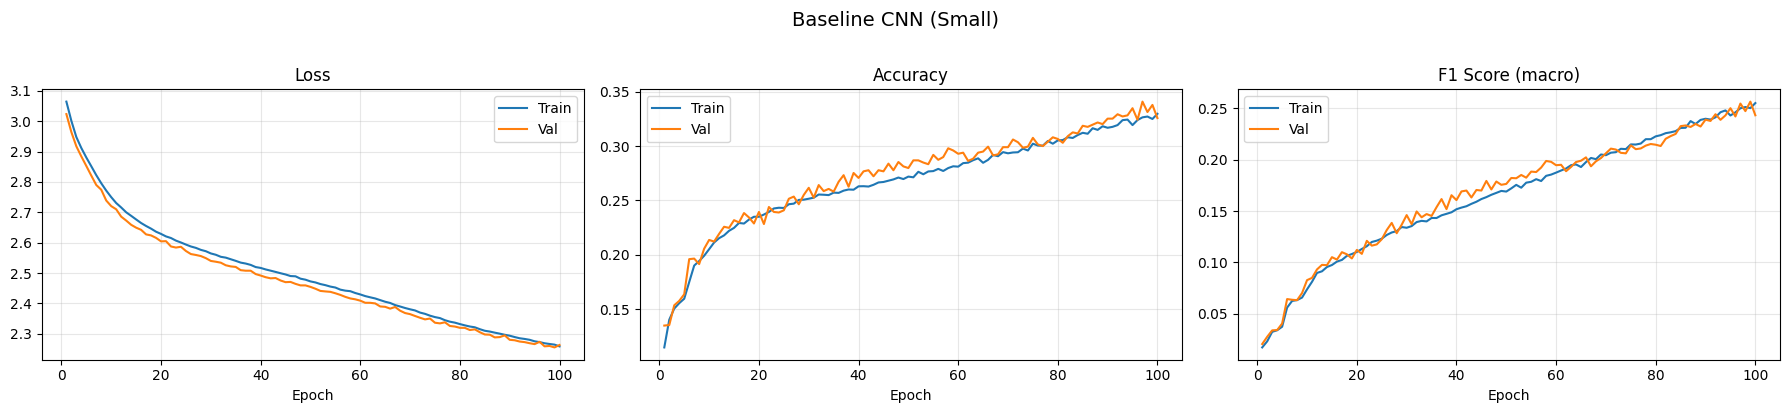

Best epoch (lowest val_loss): 99
  Val Loss: 2.2548
  Val Acc:  0.3379
  Val F1:   0.2566


In [5]:
plot_learning_curves(history, title="Baseline CNN (Small)")

<div id="3-model2" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    3. Model Evaluation
  </h2>
</div>

### Test Evaluation


  Baseline CNN (Small) - Test Evaluation
  Test Loss:     2.2982
  Test Accuracy: 0.3101
  Test F1 Macro: 0.2429

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.40      0.54      0.46        87
      Boris_Kustodiev       0.17      0.03      0.05        67
     Camille_Pissarro       0.24      0.30      0.27        93
        Childe_Hassam       0.12      0.03      0.05        58
         Claude_Monet       0.26      0.40      0.32       141
          Edgar_Degas       0.00      0.00      0.00        65
        Eugene_Boudin       0.57      0.07      0.12        59
         Gustave_Dore       0.54      0.81      0.65        80
           Ilya_Repin       0.33      0.24      0.28        58
      Ivan_Aivazovsky       0.54      0.36      0.43        61
        Ivan_Shishkin       0.36      0.31      0.33        55
  John_Singer_Sargent       0.34      0.31      0.33        83
         Marc_Chagall       0.19      0.10

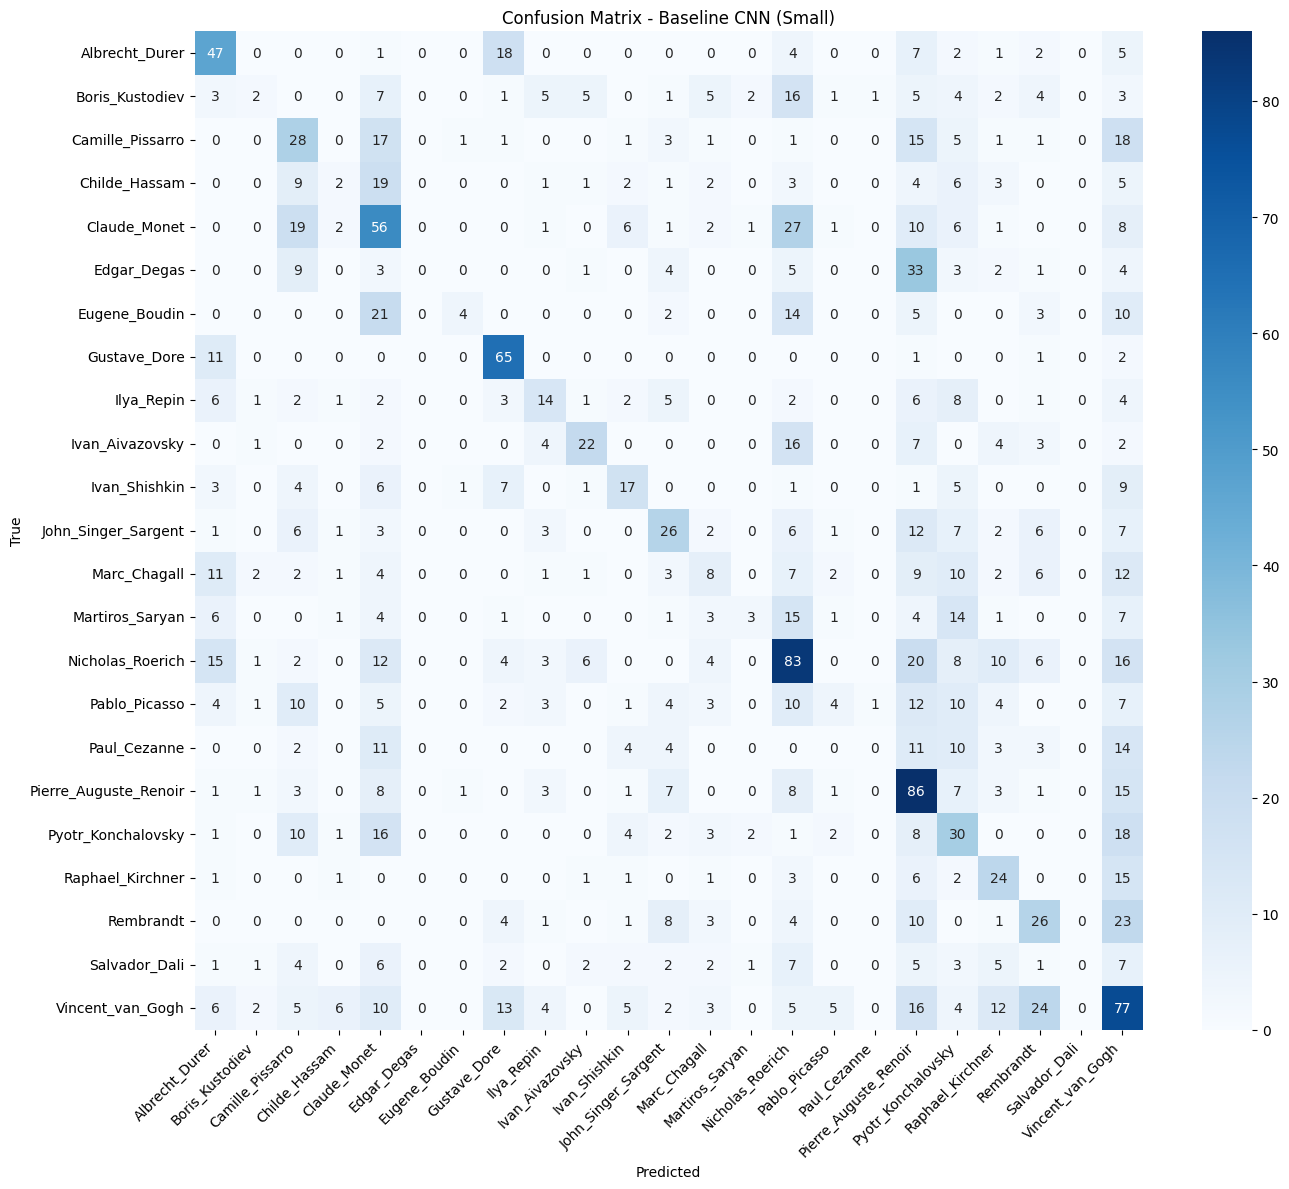

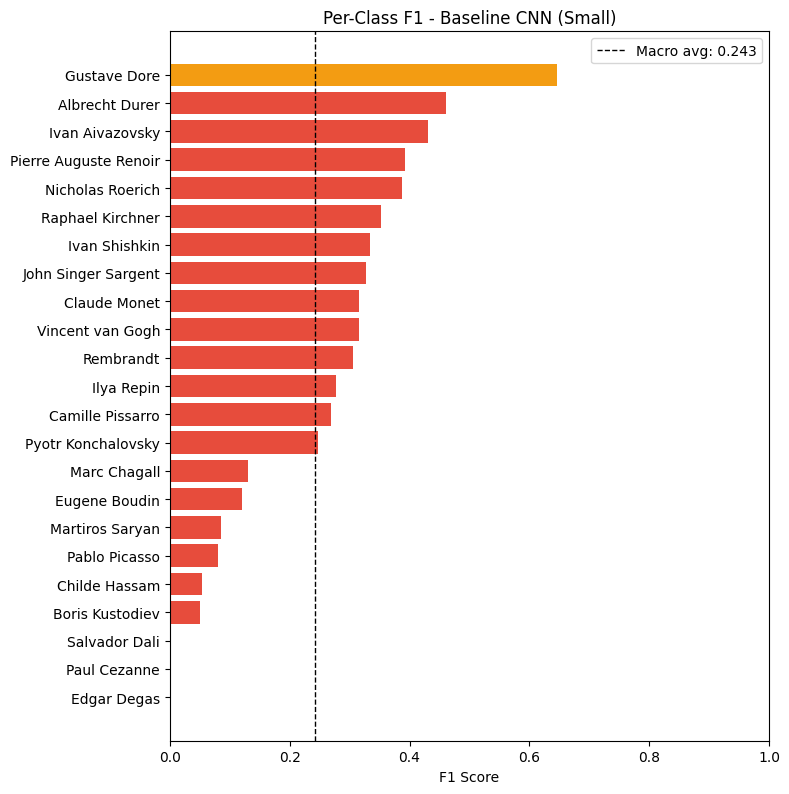

In [6]:
metrics_cnn = evaluate_model(model, test_ds, class_names, "Baseline CNN (Small)")

In [7]:
save_history(history,config['models']['baseline']['history'])

History saved to ../models/baseline/baseline_history.json
